In [6]:
# FFNN for quantum spin models
# honeycomb lattice Kitaev model
# python 3.8 and netket 2.1
# not very competetive:
# the variational energy is significantly higher than the exact value

import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

# costant, square root of 3
R3 = math.sqrt(3.0)

# number of unit cells L*L
L = 4

# set up the honeycomb lattice
g=nk.graph.Lattice(basis_vectors=[[1.5,0.5*R3],[0,R3]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[1,0]]) 

# Hilbert space for spin 1/2, confined to S_z=0, hopfully speed things up.
hi = nk.hilbert.Spin(graph=g, s=0.5, total_sz=0)

# Pauli Matrices
sigmaz = [[1, 0], [0, -1]]
sigmax = [[0, 1], [1, 0]]
sigmay = [[0, -1j], [1j, 0]]

# empty lists to store the sites (pair) and the corresponding operators (exchange interaction)
operators = []
sites = []

# Bookkeeping: number of sites, must be even 
Ns=g.n_sites
assert Ns % 2 == 0
# number of unit cells
Nu = int(Ns/2)
# shifting needed going from A to the B site
shift = Nu

# loop over the unit cells
for i in range(Nu):
    
    # horizontal bond, xx coupling,
    sites.append([i, (i+shift)])
    operators.append((np.kron(sigmax,sigmax)).tolist())
    
    # lattice coordinates
    [m,n] = g.site_to_vector(i) 
    
    # northeast-southwest bond, yy coupling
    # the unit cell, shift m to left (-1), modulo L 
    newvec = [(m-1)%L,n] 
    k = g.vector_to_site(newvec)
    sites.append([i,(k+shift)])
    # alternatively, hardcode it:
    # sites.append([i,((i-L)%Nu+shift)])
    operators.append((np.kron(sigmay,sigmay)).tolist())
    
    # northwest-southeast bond, zz coupling    
    newvec = [(m-1)%L,(n+1)%L]
    k = g.vector_to_site(newvec)
    sites.append([i,(k+shift)])
    operators.append((np.kron(sigmaz,sigmaz)).tolist())
    
# set up the Hamiltonian using the sites and operators
ham = nk.operator.LocalOperator(hi, operators=operators, acting_on=sites)

# set up the FFNN
# alpha = 2, can also be fractional value
# layer choice: Relu, Tanh
# can add more layers
alpha = 2
layers = (nk.layer.FullyConnected(input_size=Ns,output_size=int(alpha*Ns),use_bias=True),
          nk.layer.Lncosh(input_size=int(alpha*Ns)),
          #nk.layer.FullyConnected(input_size=int(alpha*Ns),output_size=int(alpha*Ns),use_bias=True),
          #nk.layer.Lncosh(input_size=int(alpha*Ns)),
          nk.layer.SumOutput(input_size=int(alpha*Ns))
         )
for layer in layers:
    layer.init_random_parameters(sigma=0.01)

# machine state can be saved or loaded
ffnn = nk.machine.FFNN(hi, layers)
#print("The FFNN machine has", ffnn.n_par, "parameters.")

# specify sampler
sa = nk.sampler.MetropolisExchange(machine=ffnn)

# Optimizer
op=nk.optimizer.Sgd(learning_rate=0.013,decay_factor=1)

# driver: Stochastic reconfiguration to ground state
gs = nk.variational.Vmc(
    hamiltonian=ham,
    sampler=sa,
    optimizer=op,
    n_samples=1000,
    diag_shift=0.1,
    use_iterative=True,
    method='Sr')

#gs.add_observable(structure_factor, "Structure Factor")

# iteration
gs.run(n_iter=1000, out='FF0')

100%|██████████| 1000/1000 [3:53:56<00:00, 14.04s/it, Energy=(-23.00 - 0.04i) ± 0.10 [var=1.91, R=1.03391]]        


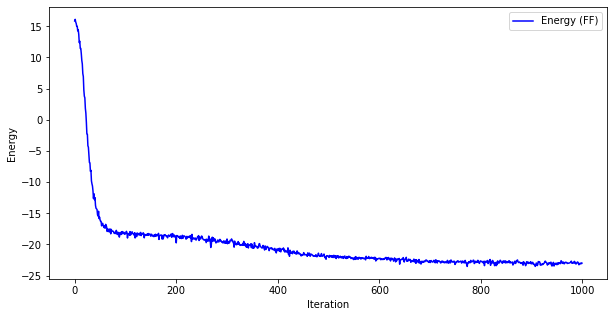

E =  -22.996237763232735
VMC samples = 1000


In [7]:
# plot the energy, alpha = 2
data=json.load(open("FF0.log"))

en = []
#sd = []
it = []
for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    #sd.append(iteration["Energy"]["Sigma"])
    it.append(iteration["Iteration"])

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(it, en, color='blue', label='Energy (FF)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

print("E = ", en[-1])
print("VMC samples =", gs.n_samples)

In [8]:
# increase n_samples in VMC, run 500 steps, 
gs.n_samples = 2000
gs.run(out='FF1', n_iter=500)

100%|██████████| 500/500 [19:48<00:00,  2.38s/it, Energy=(-23.83 + 0.05i) ± 0.14 [var=2.92, R=1.04714]]    


According to arXiv/2003.07280, the exact energy is E = -25.4164
Here, the average energy of the last 100 steps is  E = -23.663531180462765


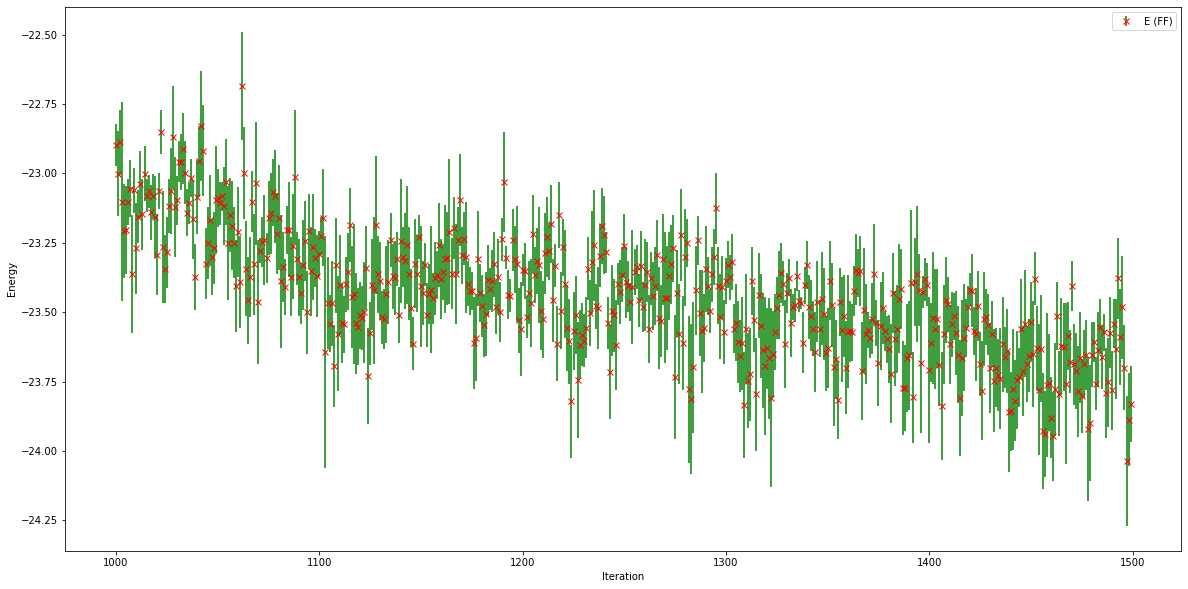

In [9]:
import statistics
en = []
de = []
st = []

data=json.load(open("FF1.log"))
    
for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    de.append(iteration["Energy"]["Sigma"])
    st.append(iteration["Iteration"])

print("According to arXiv/2003.07280, the exact energy is E = -25.4164")
print("Here, the average energy of the last 100 steps is  E =", statistics.mean(en[-100:]))        
      
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.errorbar(st, en, yerr=de, color='r', label='E (FF)', fmt='x', ecolor='g', capthick=1)
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

In [12]:
# increase n_samples in VMC, run 500 steps, 
gs.n_samples = 2000
gs.run(out='FF2', n_iter=500)

100%|██████████| 500/500 [21:52<00:00,  2.63s/it, Energy=(-24.25 - 0.03i) ± 0.11 [var=1.10, R=1.07501]]    


According to arXiv/2003.07280, the exact energy is E = -25.4164
Here, the average energy of the last 100 steps is  E = -24.307158957122336


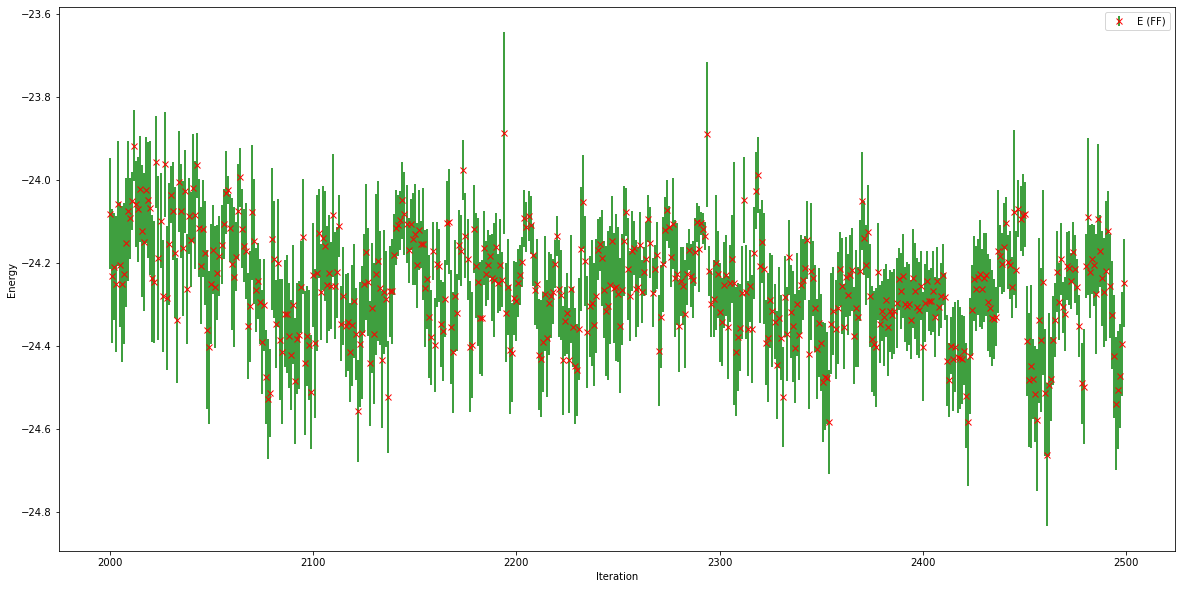

In [13]:
import statistics
en = []
de = []
st = []

data=json.load(open("FF2.log"))
    
for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    de.append(iteration["Energy"]["Sigma"])
    st.append(iteration["Iteration"])

print("According to arXiv/2003.07280, the exact energy is E = -25.4164")
print("Here, the average energy of the last 100 steps is  E =", statistics.mean(en[-100:]))        
      
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.errorbar(st, en, yerr=de, color='r', label='E (FF)', fmt='x', ecolor='g', capthick=1)
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

In [1]:
# FFNN for quantum spin models
# honeycomb lattice Kitaev model
# python 3.8 and netket 2.1

import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

# costant, square root of 3
R3 = math.sqrt(3.0)

# number of unit cells L*L
L = 4

# set up the honeycomb lattice
g=nk.graph.Lattice(basis_vectors=[[1.5,0.5*R3],[0,R3]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[1,0]]) 

# Hilbert space for spin 1/2, confined to S_z=0, hopfully speed things up.
hi = nk.hilbert.Spin(graph=g, s=0.5, total_sz=0)

# Pauli Matrices
sigmaz = [[1, 0], [0, -1]]
sigmax = [[0, 1], [1, 0]]
sigmay = [[0, -1j], [1j, 0]]

# empty lists to store the sites (pair) and the corresponding operators (exchange interaction)
operators = []
sites = []

# Bookkeeping: number of sites, must be even 
Ns=g.n_sites
assert Ns % 2 == 0
# number of unit cells
Nu = int(Ns/2)
# shifting needed going from A to the B site
shift = Nu

# loop over the unit cells
for i in range(Nu):
    
    # horizontal bond, xx coupling,
    sites.append([i, (i+shift)])
    operators.append((np.kron(sigmax,sigmax)).tolist())
    
    # lattice coordinates
    [m,n] = g.site_to_vector(i) 
    
    # northeast-southwest bond, yy coupling
    # the unit cell, shift m to left (-1), modulo L 
    newvec = [(m-1)%L,n] 
    k = g.vector_to_site(newvec)
    sites.append([i,(k+shift)])
    # alternatively, hardcode it:
    # sites.append([i,((i-L)%Nu+shift)])
    operators.append((np.kron(sigmay,sigmay)).tolist())
    
    # northwest-southeast bond, zz coupling    
    newvec = [(m-1)%L,(n+1)%L]
    k = g.vector_to_site(newvec)
    sites.append([i,(k+shift)])
    operators.append((np.kron(sigmaz,sigmaz)).tolist())
    
# set up the Hamiltonian using the sites and operators
ham = nk.operator.LocalOperator(hi, operators=operators, acting_on=sites)

# set up the FFNN
alpha = 1.5
layers = (nk.layer.FullyConnected(input_size=Ns,output_size=int(alpha*Ns),use_bias=True),
          nk.layer.Lncosh(input_size=int(alpha*Ns)),
          #nk.layer.FullyConnected(input_size=int(alpha*Ns),output_size=int(alpha*Ns),use_bias=True),
          #nk.layer.Lncosh(input_size=int(alpha*Ns)),
          nk.layer.SumOutput(input_size=int(alpha*Ns))
         )
for layer in layers:
    layer.init_random_parameters(sigma=0.01)

# machine state can be saved or loaded
ffnn = nk.machine.FFNN(hi, layers)
#print("The FFNN machine has", ffnn.n_par, "parameters.")

# specify sampler
sa = nk.sampler.MetropolisExchange(machine=ffnn)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.02, decay_factor=1)

# driver: Stochastic reconfiguration to ground state
gs = nk.variational.Vmc(
    hamiltonian=ham,
    sampler=sa,
    optimizer=op,
    n_samples=1000,
    diag_shift=0.1,
    use_iterative=True,
    method='Sr')

# iteration
gs.run(n_iter=650, out='FF3')

100%|██████████| 650/650 [10:39<00:00,  1.02it/s, Energy=(-21.58 + 0.37i) ± 0.11 [var=1.06, R=1.08319]]    


According to arXiv/2003.07280, the exact energy is E = -25.4164
-21.578433763715474


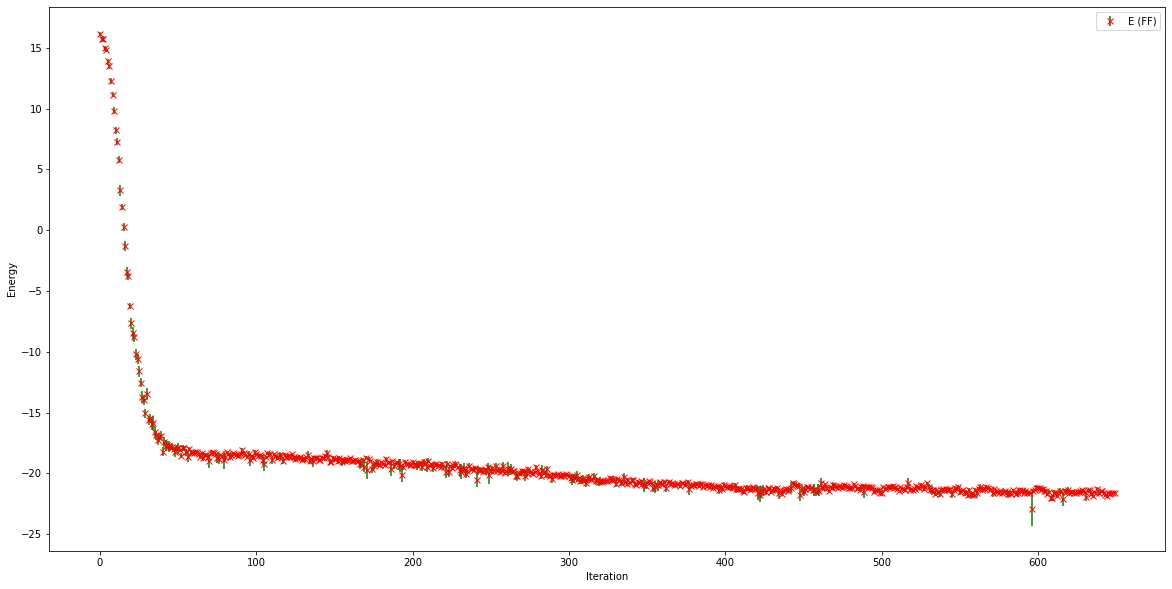

In [2]:
# alpha = 1.5 
en = []
de = []
st = []

data=json.load(open("FF3.log"))
    
for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    de.append(iteration["Energy"]["Sigma"])
    st.append(iteration["Iteration"])

print("According to arXiv/2003.07280, the exact energy is E = -25.4164")
print(en[-1])      
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.errorbar(st, en, yerr=de, color='r', label='E (FF)', fmt='x', ecolor='g', capthick=1)
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

In [7]:
# increase n_samples in VMC, run 500 steps, 
gs.n_samples = 4000
gs.run(n_iter=500, out='FF4')

100%|██████████| 500/500 [27:32<00:00,  3.31s/it, Energy=(-22.942 + 0.111i) ± 0.086 [var=2.341, R=1.02300]] 


According to arXiv/2003.07280, the exact energy is E = -25.4164
Here, the average energy of the last 100 steps is  E = -22.73095922347235


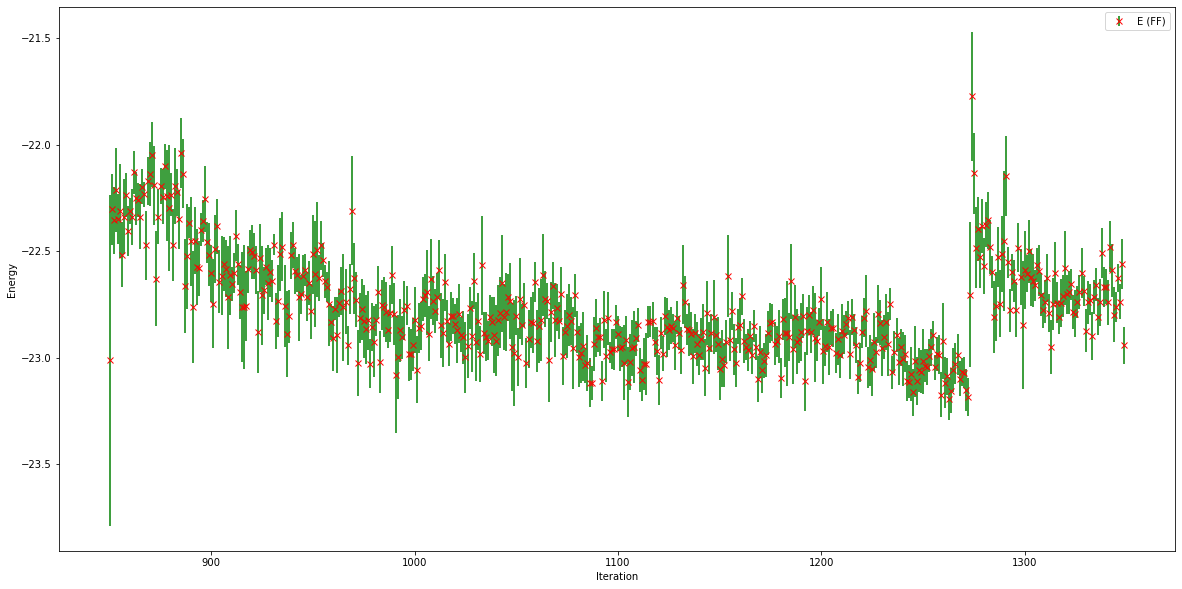

In [8]:
import statistics
en = []
de = []
st = []

data=json.load(open("FF4.log"))
    
for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    de.append(iteration["Energy"]["Sigma"])
    st.append(iteration["Iteration"])

print("According to arXiv/2003.07280, the exact energy is E = -25.4164")
print("Here, the average energy of the last 100 steps is  E =", statistics.mean(en[-100:]))        
      
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.errorbar(st, en, yerr=de, color='r', label='E (FF)', fmt='x', ecolor='g', capthick=1)
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()